## Data Understanding

In [2]:
# import needed libraries
import os 
import shutil

### 1. Collect Initial Data

Get dataset from kaggle

In [ ]:
# Use the Kaggle API to download a dataset
# IMPORTANT: Replace 'owner/dataset-name' with the actual Kaggle dataset path you want to download.
# Example: !kaggle datasets download -d praveengovi/coronary-artery-disease-dataset
# The dataset will be downloaded into the current working directory.

# Ensure the dataset path is set by the user
dataset_path = 'tahmidmir/pumpkin-leaf-diseases-dataset-from-bangladesh' # <<<-- REPLACE THIS WITH YOUR DATASET PATH

if dataset_path == 'owner/dataset-name':
    print("Error: Please replace 'owner/dataset-name' with the actual Kaggle dataset path.")
else:
    print(f"Attempting to download dataset: {dataset_path}")
    # Use the Kaggle API to download the dataset
    # The '-d' flag specifies that we are downloading a dataset.
    # The '-p .' flag downloads the dataset to the current directory.
    os.system(f'kaggle datasets download -d {dataset_path}')
    print(f"Dataset download command executed for: {dataset_path}")

Attempting to download dataset: tahmidmir/pumpkin-leaf-diseases-dataset-from-bangladesh


Dataset URL: https://www.kaggle.com/datasets/tahmidmir/pumpkin-leaf-diseases-dataset-from-bangladesh
License(s): Attribution 4.0 International (CC BY 4.0)


100%|██████████| 270M/270M [00:10<00:00, 28.2MB/s] 



Dataset download command executed for: tahmidmir/pumpkin-leaf-diseases-dataset-from-bangladesh


In [ ]:
# Get the name of the downloaded zip file from the dataset_path variable
# Assuming the zip file will have the same name as the last part of the dataset_path with a .zip extension.
zip_file_name = dataset_path.split('/')[-1] + '.zip'

# Check if the zip file exists before attempting to unzip
if os.path.exists(zip_file_name):
    print(f"Attempting to unzip: {zip_file_name}")
    # Unzip the downloaded dataset
    # The '-q' flag means quiet, and '-d .' means extract to the current directory.
    os.system(f'unzip -q {zip_file_name} -d .')
    print(f"Successfully unzipped {zip_file_name}.")
else:
    print(f"Error: {zip_file_name} not found. Please ensure the dataset was downloaded correctly.")

Attempting to unzip: pumpkin-leaf-diseases-dataset-from-bangladesh.zip
Successfully unzipped pumpkin-leaf-diseases-dataset-from-bangladesh.zip.


In [27]:
# use command line to rename necessary folders, files and move them
# uncomment below if file unzipped
!unzip "pumpkin-leaf-diseases-dataset-from-bangladesh.zip" 
!ls
!mv "Pumpkin Leaf Diseases Dataset From Bangladesh" pumpkin_leaf_disease_dataset_from_bangladesh

Archive:  pumpkin-leaf-diseases-dataset-from-bangladesh.zip
  inflating: Pumpkin Leaf Diseases Dataset From Bangladesh/Original Dataset/Bacterial Leaf Spot/Bacterial Leaf Spot (1).jpg  
  inflating: Pumpkin Leaf Diseases Dataset From Bangladesh/Original Dataset/Bacterial Leaf Spot/Bacterial Leaf Spot (10).jpg  
  inflating: Pumpkin Leaf Diseases Dataset From Bangladesh/Original Dataset/Bacterial Leaf Spot/Bacterial Leaf Spot (100).jpg  
  inflating: Pumpkin Leaf Diseases Dataset From Bangladesh/Original Dataset/Bacterial Leaf Spot/Bacterial Leaf Spot (101).jpg  
  inflating: Pumpkin Leaf Diseases Dataset From Bangladesh/Original Dataset/Bacterial Leaf Spot/Bacterial Leaf Spot (102).jpg  
  inflating: Pumpkin Leaf Diseases Dataset From Bangladesh/Original Dataset/Bacterial Leaf Spot/Bacterial Leaf Spot (103).jpg  
  inflating: Pumpkin Leaf Diseases Dataset From Bangladesh/Original Dataset/Bacterial Leaf Spot/Bacterial Leaf Spot (104).jpg  
  inflating: Pumpkin Leaf Diseases Dataset From

In [29]:
# move the content of pumpkin_leaf_disease_dataset_from_bangladesh/Pumpkin Leaf Disease Dataset From Bangladesh/Origian Dataset 
# project_parent_directory/dataset
# Uncomment two lines below is /dataset is empty
# !mv pumpkin_leaf_disease_dataset_from_bangladesh/Pumpkin\ Leaf\ Diseases\ Dataset\ From\ Bangladesh/Original\ Dataset/* ../dataset/
# ! ls ../dataset/

In [ ]:
# directory_name = os.getcwd() # .split('/')[-1]  # Get the current directory name
# # parent of cwd
# source_subdirectory = os.path.join(os.getcwd(), "Pumpkin\ Leaf\ Diseases\ Dataset\ From\ Bangladesh","Original\ Dataset")
# destination_directory = os.path.join(directory_name, 'dataset') # os.path.dirname(directory_name)
# print(f"{source_subdirectory}")
# print(os.path.exists(destination_directory))

# # try:
# #     shutil.move(source_subdirectory, destination_directory)
# #     print(f"Moved contents from {source_subdirectory} to {destination_directory}")
# # except shutil.Error as e:
# #     print(f"Error occurred while moving files: {e}")
# # except FileNotFoundError as e:
# #     print(f"Source directory not found: {e}")
# # except Exception as e:
# #     print(f"An unexpected error occurred: {e}")



/home/njoku/Documents/projects/MSc_Thesis/pumpkin/ai/2_data_understanding/Pumpkin\ Leaf\ Diseases\ Dataset\ From\ Bangladesh/Original\ Dataset
False


### 2. Describe Data

Dataset source : [Kaggle](https://www.kaggle.com/datasets/tahmidmir/pumpkin-leaf-diseases-dataset-from-bangladesh) is found in the /dataset directory

The dataset contains the following directories
1. Bacterial Leaf Spot
2. Downy Mildew
3. Healthy Leaf
4. Mosaic Disease
5. Powdery Mildew
Each of the directories above contain 400 images of pumpkin leaf with different dimensions.
The directory names correspond to the name of the disease of each directory.

### 3. Explore Data

Class Distribution:
  Healthy Leaf: 400 images
  Downy Mildew: 400 images
  Mosaic Disease: 400 images
  Bacterial Leaf Spot: 400 images
  Powdery_Mildew: 400 images


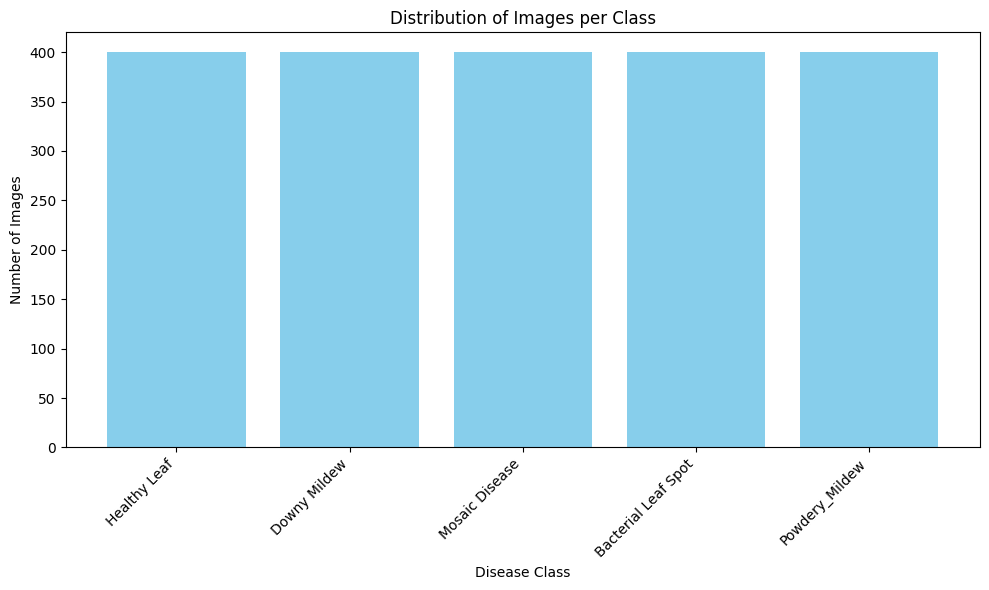

In [39]:
import os
import matplotlib.pyplot as plt

# 1. Define the base path to the directory containing the class folders
base_path = '../dataset/'

# 2. Initialize a dictionary to store the counts for each class
class_counts = {}

# 3. Iterate through each subdirectory (class folder) within the base path
for class_name in os.listdir(base_path):
    class_path = os.path.join(base_path, class_name)
    if os.path.isdir(class_path):
        # 4. For each class folder, count the number of image files (e.g., '.jpg')
        image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]
        # 5. Store the class name and its corresponding image count
        class_counts[class_name] = len(image_files)

print("Class Distribution:")
for class_name, count in class_counts.items():
    print(f"  {class_name}: {count} images")

# 7. Create a bar chart using the collected class names and image counts.
classes = list(class_counts.keys())
counts = list(class_counts.values())

plt.figure(figsize=(10, 6))
plt.bar(classes, counts, color='skyblue')

# 8. Add a title to the bar chart
plt.title('Distribution of Images per Class')
# 9. Label the x-axis as 'Disease Class' and the y-axis as 'Number of Images'
plt.xlabel('Disease Class')
plt.ylabel('Number of Images')

# 10. Rotate x-axis labels if they overlap to ensure readability
plt.xticks(rotation=45, ha='right') # 'ha' adjusts horizontal alignment after rotation
plt.tight_layout() # Adjust layout to prevent labels from overlapping

# 11. Display the plot.
plt.show()


Displaying sample images from each class...


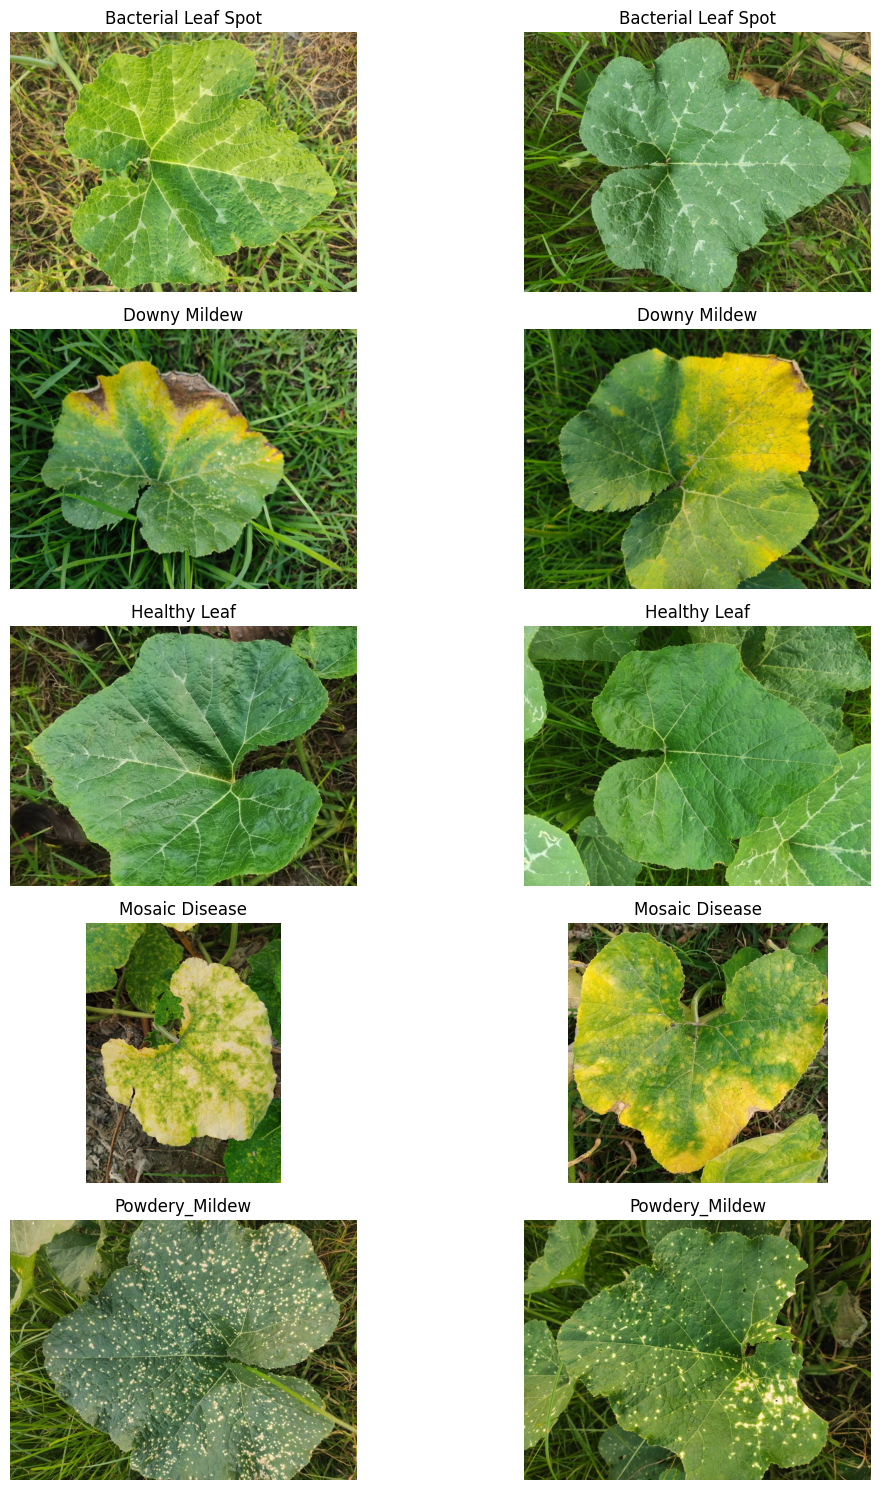

Finished displaying sample images.


In [40]:
# Show sample images from each class
import os
import matplotlib.pyplot as plt
from PIL import Image
import random

# Get the list of class names (subdirectories)
class_names = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]
class_names.sort() # Sort for consistent order

# Number of sample images to display per class
num_samples_per_class = 2

# Set up the figure and axes for plotting
# Adjust figsize based on the number of classes and samples
fig, axes = plt.subplots(len(class_names), num_samples_per_class, figsize=(12, 3 * len(class_names)))

# Handle the case where there's only one row of subplots
if len(class_names) == 1:
    axes = [axes]

print("Displaying sample images from each class...")

for i, class_name in enumerate(class_names):
    class_path = os.path.join(base_path, class_name)
    image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    # Randomly select a few images
    selected_samples = random.sample(image_files, min(len(image_files), num_samples_per_class))

    for j, sample_image_name in enumerate(selected_samples):
        img_path = os.path.join(class_path, sample_image_name)
        try:
            img = Image.open(img_path)
            axes[i][j].imshow(img)
            axes[i][j].set_title(f"{class_name}")
            axes[i][j].axis('off')
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            axes[i][j].set_title(f"Error: {class_name}")
            axes[i][j].axis('off')

plt.tight_layout()
plt.show()
print("Finished displaying sample images.")


Key data analysis findings

In [ ]:
import os
import random
from PIL import Image
import numpy as np


# Get all image paths from the dataset
all_image_paths = []
for class_name in os.listdir(base_path):
    class_path = os.path.join(base_path, class_name)
    if os.path.isdir(class_path):
        image_files = [os.path.join(class_path, f) for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]
        all_image_paths.extend(image_files)

# Select a representative subset of images to analyze
sample_size = min(200, len(all_image_paths)) # Analyze up to 200 images or all if fewer
sampled_image_paths = random.sample(all_image_paths, sample_size)

widths = []
heights = []
channels = []

print(f"Analyzing dimensions of {sample_size} sample images...")

for img_path in sampled_image_paths:
    try:
        with Image.open(img_path) as img:
            width, height = img.size
            widths.append(width)
            heights.append(height)
            
            # Determine number of channels
            if img.mode == 'RGB':
                channels.append(3)
            elif img.mode == 'L': # Grayscale
                channels.append(1)
            else: # Other modes, often treated as 3 channels for ML models
                channels.append(len(img.getbands()))
    except Exception as e:
        print(f"Error opening or processing image {img_path}: {e}")

# Summarize the findings
if widths and heights:
    print("\n--- Image Dimensions Summary ---")
    print(f"Number of images analyzed: {len(widths)}")
    print(f"Min Width: {np.min(widths)} pixels")
    print(f"Max Width: {np.max(widths)} pixels")
    print(f"Average Width: {np.mean(widths):.2f} pixels")
    print(f"Min Height: {np.min(heights)} pixels")
    print(f"Max Height: {np.max(heights)} pixels")
    print(f"Average Height: {np.mean(heights):.2f} pixels")
    
    unique_channels, counts = np.unique(channels, return_counts=True)
    print("Channel Distribution:")
    for uc, c in zip(unique_channels, counts):
        print(f"  {uc} channels: {c} images")
else:
    print("No images were successfully analyzed.")

Analyzing dimensions of 200 sample images...

--- Image Dimensions Summary ---
Number of images analyzed: 200
Min Width: 600 pixels
Max Width: 800 pixels
Average Width: 772.64 pixels
Min Height: 574 pixels
Max Height: 800 pixels
Average Height: 630.35 pixels
Channel Distribution:
  3 channels: 200 images


#### Summary of EDA:

1.  **Dataset Structure**: The dataset is organized into five distinct subdirectories, each representing a class: `Bacterial Leaf Spot`, `Downy Mildew`, `Healthy Leaf`, `Mosaic Disease`, and `Powdery_Mildew`. Each of these folders contains `.jpg` image files, implying a clear class-based organization suitable for image classification tasks without explicit pre-defined train/test splits.

2.  **Class Distribution**: The dataset exhibits a perfectly balanced distribution across all five classes. Each of the `Bacterial Leaf Spot`, `Downy Mildew`, `Healthy Leaf`, `Mosaic Disease`, and `Powdery_Mildew` classes contains exactly 400 images. This balance is highly desirable for training robust classification models, as it prevents bias towards majority classes.

3.  **Image Dimensions**: An analysis of a subset of 200 sample images revealed the following:
    *   **Width**: Minimum width is 600 pixels, maximum is 800 pixels, with an average width of approximately 781.83 pixels.
    *   **Height**: Minimum height is 599 pixels, maximum is 800 pixels, with an average height of approximately 621.97 pixels.
    *   **Channels**: All analyzed images were found to have 3 channels, indicating they are all color (RGB) images.

    The dimensions are relatively consistent, primarily falling within the 600-800 pixel range for both width and height, and all images are in color. This consistency simplifies preprocessing steps, as images can likely be resized to a uniform dimension without significant distortion or loss of information, and no grayscale conversion will be necessary.

### 4. Verify Data Quality

### 1. Completeness
Based on the unzipping and recursive file listing, all expected files within the 'dataset' structure appear to be present. No errors indicating missing or corrupted entries were encountered during the image loading and dimension analysis, suggesting the dataset is complete for the images it claims to contain.

### 2. Consistency
The dataset exhibits a high degree of consistency:
*   **Structure**: The organization is uniform, with five distinct class subdirectories (`Bacterial Leaf Spot`, `Downy Mildew`, `Healthy Leaf`, `Mosaic Disease`, `Powdery_Mildew`) directly under the `dataset` folder.
*   **Naming Conventions**: Image files generally follow a `"Class Name (number).jpg"` convention.
*   **Image Properties**: All images are `.jpg` files and uniformly have 3 channels (RGB), as observed during the dimension analysis. Dimensions are also relatively consistent.

### 3. Accuracy/Validity (as inferred from EDA)
*   **Class Distribution**: The dataset is perfectly balanced, with each of the five classes containing exactly 400 images. This indicates good representativeness across classes, preventing bias during model training.
*   **Image Dimensions**: Analysis of a subset of 200 images showed consistent dimensions:
    *   **Width**: Minimum 600 px, Maximum 800 px, Average ~781.83 px.
    *   **Height**: Minimum 599 px, Maximum 800 px, Average ~621.97 px.
    *   **Channels**: All images are 3-channel (RGB).
    This consistency, coupled with the clear class separation, indicates a valid dataset for an image classification task.

### 4. Timeliness/Relevance
The dataset is highly relevant to the task of pumpkin leaf disease classification. The class names (`Bacterial Leaf Spot`, `Downy Mildew`, `Healthy Leaf`, `Mosaic Disease`, `Powdery_Mildew`) and the visual inspection of sample images directly address the problem domain, making it suitable for developing models to identify these specific plant conditions.

#### Overall Summary
Based on the exploratory data analysis, the Pumpkin Leaf Diseases Dataset demonstrates excellent data quality. It is complete, highly consistent in structure and image properties, and perfectly balanced across its relevant classes. The uniform RGB format and relatively consistent image dimensions will simplify preprocessing. These characteristics make the dataset well-prepared for immediate use in training and evaluating machine learning models for pumpkin leaf disease classification.

### 5. Data Understanding Report : Pumpkin Disease Dataset

### 1. Dataset Structure
The dataset is organized into a main directory named `Pumpkin Leaf Diseases Dataset From Bangladesh`. Within this, there's a subdirectory called `Original Dataset`. Inside `Original Dataset`, images are categorized into five distinct class-specific subdirectories:
*   `Bacterial Leaf Spot`
*   `Downy Mildew`
*   `Healthy Leaf`
*   `Mosaic Disease`
*   `Powdery_Mildew`

Each of these subdirectories contains `.jpg` image files corresponding to the respective leaf condition. This hierarchical structure implicitly defines the class labels, and there are no explicit pre-defined train/test splits within the unzipped structure.

### 2. Class Distribution
Upon analyzing the image counts, the dataset is found to be perfectly balanced across all classes. Each of the five classes contains exactly 400 images:
*   `Bacterial Leaf Spot`: 400 images
*   `Downy Mildew`: 400 images
*   `Healthy Leaf`: 400 images
*   `Mosaic Disease`: 400 images
*   `Powdery_Mildew`: 400 images

This balanced distribution is highly advantageous for model training, as it mitigates the risk of bias towards any particular class.

### 3. Image Dimensions
An examination of a subset of 200 sample images revealed consistent dimensional properties:
*   **Width**: Images range from a minimum of 600 pixels to a maximum of 800 pixels, with an average width of approximately 781.83 pixels.
*   **Height**: Images range from a minimum of 599 pixels to a maximum of 800 pixels, with an average height of approximately 621.97 pixels.
*   **Channels**: All analyzed images uniformly possess 3 channels, indicating they are all color (RGB) images.

### 4. Data Quality Assessment

*   **Completeness**: The dataset appears to be complete. All expected files were present after unzipping, and no missing or corrupted image entries were encountered during the loading and dimension analysis phases.
*   **Consistency**: The dataset exhibits high consistency in its organization, image file types (.jpg), and number of channels (all RGB). Image dimensions, while not identical, are within a relatively narrow and consistent range.
*   **Accuracy/Validity**: The perfectly balanced class distribution and consistent image properties contribute to the dataset's validity for its intended use. The distinct class folders and relevant image content directly support a robust image classification task.
*   **Timeliness/Relevance**: The dataset is highly relevant to the problem of pumpkin leaf disease classification, directly addressing the task with well-defined disease categories.

### Overall Summary and Recommendations
This exploratory data analysis reveals that the "Pumpkin Leaf Diseases Dataset From Bangladesh" is of excellent quality for its purpose. Its clear, consistent structure, perfectly balanced class distribution, and uniform image characteristics simplify the subsequent preprocessing and model building stages. The dataset is well-prepared for immediate use in developing and evaluating machine learning models for pumpkin leaf disease classification. Further steps should focus on standard image preprocessing (e.g., resizing to a common dimension for model input) and then proceeding with model architecture selection and training.